In [3]:
import pandas as pd
bert_data = pd.read_parquet("/Users/yavuzlule/Desktop/bsc-relish/data/interim/chunked_256/2026-04-30_15-29-41/dataset.parquet")
roberta_data = pd.read_parquet("/Users/yavuzlule/Desktop/bsc-relish/data/interim/b2drop_v1/output_with_probabilities.parquet")

bert_data.head()

,label,file_name,file_path,parent_folder,chunk_text,chunk_index
0,0,halbjahrsverzei02abtegoog_djvu.txt,data/raw/non_cooking/filtered_non_cooking/halb...,filtered_non_cooking,Google This is a digital copy of a book that w...,0
1,0,halbjahrsverzei02abtegoog_djvu.txt,data/raw/non_cooking/filtered_non_cooking/halb...,filtered_non_cooking,"machinc translation, optical character recogni...",1
2,0,halbjahrsverzei02abtegoog_djvu.txt,data/raw/non_cooking/filtered_non_cooking/halb...,filtered_non_cooking,"Realen der Bibliotheken aufbewahrt wurde, bevo...",2
3,0,halbjahrsverzei02abtegoog_djvu.txt,data/raw/non_cooking/filtered_non_cooking/halb...,filtered_non_cooking,"über maschinelle Übersetzung, optische Zeichen...",3
4,0,halbjahrsverzei02abtegoog_djvu.txt,data/raw/non_cooking/filtered_non_cooking/halb...,filtered_non_cooking,unb neu aitfgelegten i / 3eitfrf)riften iij 18...,4


In [2]:
bert_data.describe()

,label,chunk_index,Roberta-base-proba
count,1287.0,1287.000000,1287.000000
mean,1.0,165.807304,0.547294
std,0.0,125.435324,0.002407
min,1.0,0.000000,0.540928
25%,1.0,64.000000,0.545606
50%,1.0,143.000000,0.547124
75%,1.0,229.000000,0.548902
max,1.0,499.000000,0.558278


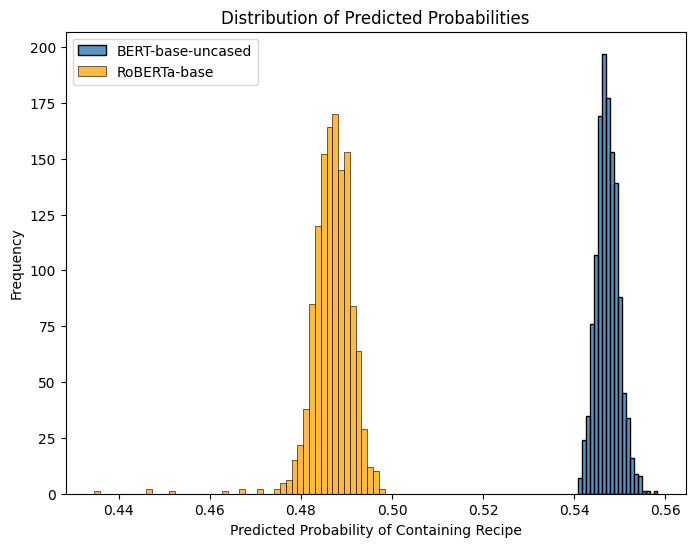

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.histplot(bert_data['Roberta-base-proba'], bins=20, kde=False)
sns.histplot(roberta_data['Roberta-base-proba'], bins=50, kde=False, color='orange')
plt.title('Distribution of Predicted Probabilities')
plt.legend(['BERT-base-uncased', 'RoBERTa-base'])
plt.xlabel('Predicted Probability of Containing Recipe')
plt.ylabel('Frequency')
plt.show()

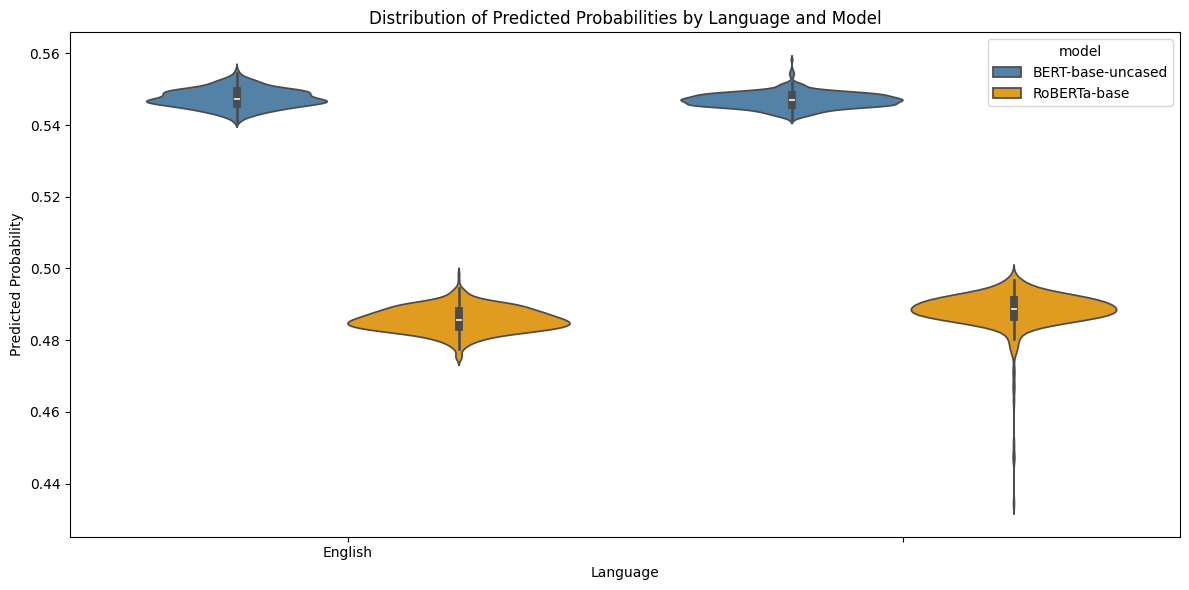

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Combine data with model identifier
bert_data['model'] = 'BERT-base-uncased'
roberta_data['model'] = 'RoBERTa-base'
combined = pd.concat([bert_data, roberta_data])

fig, ax = plt.subplots(figsize=(12, 6))

sns.violinplot(
    data=combined,
    x='language',
    y='Roberta-base-proba',
    hue='model',
    ax=ax,
    palette=['steelblue', 'orange']
)

ax.set_title('Distribution of Predicted Probabilities by Language and Model')
ax.set_xlabel('Language')
ax.set_ylabel('Predicted Probability')
plt.tight_layout()
plt.show()

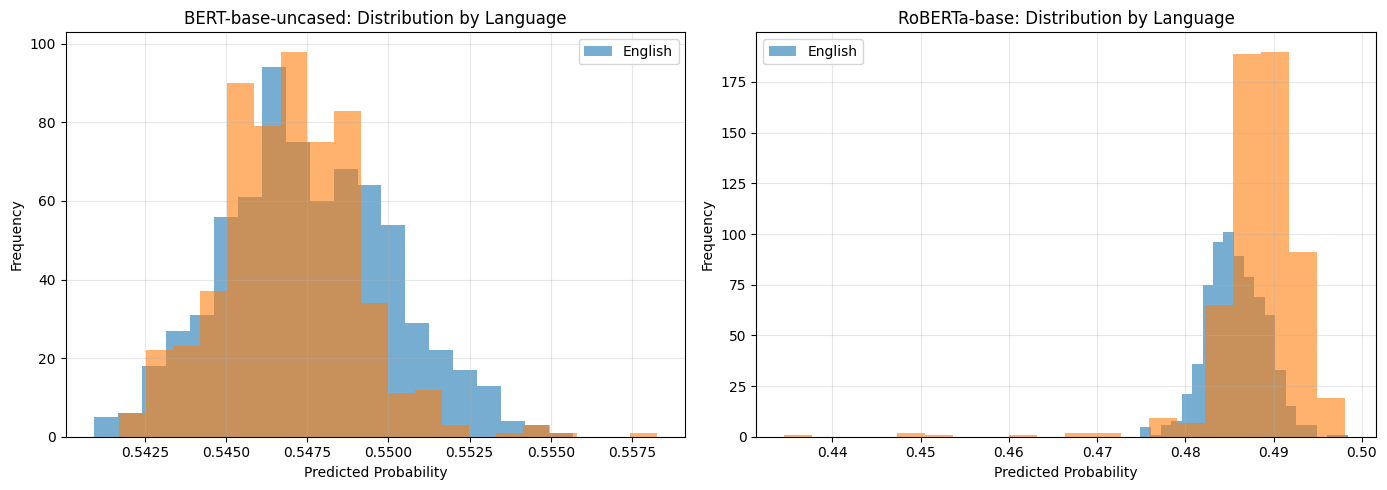

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your DataFrames have 'language' and 'Roberta-base-proba' columns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Get unique languages
languages = bert_data['language'].unique()

# Plot for BERT
ax1 = axes[0]
for lang in languages:
    lang_data = bert_data[bert_data['language'] == lang]['Roberta-base-proba']
    ax1.hist(lang_data, bins=20, alpha=0.6, label=lang)

ax1.set_title('BERT-base-uncased: Distribution by Language')
ax1.set_xlabel('Predicted Probability')
ax1.set_ylabel('Frequency')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot for RoBERTa
ax2 = axes[1]
for lang in languages:
    lang_data = roberta_data[roberta_data['language'] == lang]['Roberta-base-proba']
    ax2.hist(lang_data, bins=20, alpha=0.6, label=lang)

ax2.set_title('RoBERTa-base: Distribution by Language')
ax2.set_xlabel('Predicted Probability')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [43]:
languages = bert_data['language'].unique()
languages

<ArrowStringArray>
['English', '']
Length: 2, dtype: str

In [24]:
# Check if weights were actually loaded
import torch
from transformers import RobertaForSequenceClassification
from safetensors.torch import load_file
from transformers import AutoModelForSequenceClassification, AutoTokenizer, RobertaForSequenceClassification, RobertaTokenizer

from bsc_relish.infer_roberta import convert_tf_to_pytorch_layernorm

def verify_model_loaded(model, model_path):
    """Verify the model was properly fine-tuned"""
    print("Checking if model is fine-tuned...")
    
    # Compare with base model
    base_model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)
    
    # Check classifier head weights
    model_classifier = model.classifier.dense.weight.data
    base_classifier = base_model.classifier.dense.weight.data
    
    difference = torch.abs(model_classifier - base_classifier).mean().item()
    print(f"Difference from base model: {difference}")
    
    if difference < 0.01:
        print("⚠️ WARNING: Model appears to be unchanged from base!")
        return False
    else:
        print("✓ Model appears to be fine-tuned")
        return True

# Usage
print("Loading tokenizer...")
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

print("Loading model architecture...")
model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)
model_path = "/Users/yavuzlule/Desktop/bsc-relish/results/roberta-base/2026-04-29_04-02-52/model.safetensors"
print("Loading safetensors weights...")
state_dict = load_file(model_path)

# Convert TensorFlow naming to PyTorch
print("Converting TensorFlow parameters to PyTorch format...")
state_dict = convert_tf_to_pytorch_layernorm(state_dict)

# Load with strict=False to handle any remaining mismatches
model.load_state_dict(state_dict, strict=False)

# Set to evaluation mode
model.eval()
print("Model loaded successfully!")
verify_model_loaded(model, model_path)

Loading tokenizer...
Loading model architecture...


Python(35720) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Loading weights: 100%|██████████| 197/197 [00:00<00:00, 21084.43it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the

Loading safetensors weights...
Converting TensorFlow parameters to PyTorch format...
Model loaded successfully!
Checking if model is fine-tuned...


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 18597.72it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Difference from base model: 0.022546427324414253
✓ Model appears to be fine-tuned


True

In [ ]:
def debug_logits(df, model_path, column_name='chunk_text', num_samples=5):
    """Check raw logits being produced"""
    print("Loading model...")
    model, tokenizer = load_roberta_model(model_path)
    
    print(f"\nChecking logits for first {num_samples} samples:\n")
    
    for idx in range(min(num_samples, len(df))):
        text = df[column_name].iloc[idx]
        
        inputs = tokenizer(
            text,
            max_length=512,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        inputs = {k: v for k, v in inputs.items()}
        
        with torch.no_grad():
            outputs = model(**inputs)
        
        logits = outputs.logits[0]
        probs = torch.softmax(logits, dim=-1)
        
        print(f"Sample {idx}:")
        print(f"  Text preview: {text[:80]}...")
        print(f"  Logits: [{logits[0].item():.4f}, {logits[1].item():.4f}]")
        print(f"  Probabilities: [{probs[0].item():.4f}, {probs[1].item():.4f}]")
        print(f"  Logit difference: {abs(logits[0].item() - logits[1].item()):.4f}")
        print()

# Usage
debug_logits(df, model_path, num_samples=5)